In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import os

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Torch version: {torch.__version__}")

Device: cuda
Torch version: 2.7.1+cu118


## 2.2 Данные и первичный анализ

В этом разделе загружается CSV-файл с временным рядом, приводится колонка `date` к типу `datetime`, выполняется сортировка по времени и базовая проверка качества данных. Мы смотрим на размер выборки, диапазон дат, количество пропусков и простую статистику по целевой переменной `target`. График `series_raw.png` позволяет визуально оценить общий тренд, сезонность и наличие выбросов, прежде чем переходить к построению моделей.

Размер датасета : (4320, 2)
Диапазон дат    : 2025-01-01 00:00:00  →  2025-06-29 23:00:00
Частота ряда    : почасовая

Пропуски по колонкам:
date      0
target    0
dtype: int64

Статистика target:
count    4320.00
mean      135.61
std        21.38
min        69.10
25%       120.54
50%       135.84
75%       150.62
max       210.10
Name: target, dtype: float64


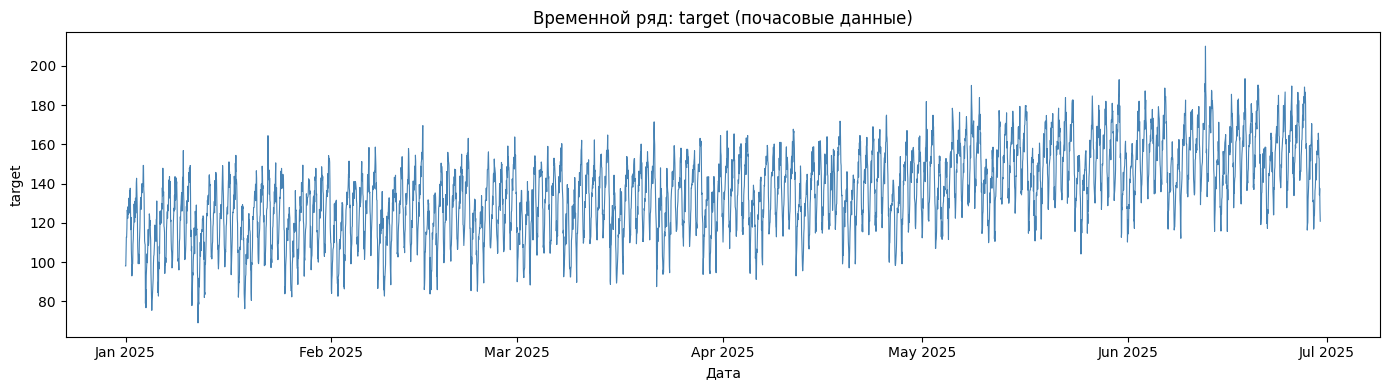

In [4]:
df = pd.read_csv("S12-hw-dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)


print(f"Размер датасета : {df.shape}")
print(f"Диапазон дат    : {df['date'].min()}  →  {df['date'].max()}")
print(f"Частота ряда    : почасовая")
print(f"\nПропуски по колонкам:")
print(df.isnull().sum())
print(f"\nСтатистика target:")
print(df["target"].describe().round(2))


fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["target"], linewidth=0.8, color="steelblue")
ax.set_title("Временной ряд: target (почасовые данные)")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig("artifacts/figures/series_raw.png", dpi=150)
plt.show()

## 2.3 Temporal split

Датасет последовательно разбивается на три части по времени: ранние наблюдения идут в `train`, средние по времени — в `validation`, а самые поздние — в `test`. Такой temporal split имитирует реальный сценарий, когда модель обучается на прошлом и проверяется на будущем, и исключает утечку информации из будущего. График `series_split.png` показывает, какие временные отрезки попали в каждую часть, и помогает убедиться, что между train/val/test нет пересечений по времени.

In [ ]:
import math

DATA_PATH = "S12-hw-dataset.csv"
ARTIFACTS_DIR = "artifacts"
FIG_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# 1. Загрузка и sanity-check данных
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Number of observations:", len(df))
print("Date range:", df["date"].min(), "-", df["date"].max())
print("Missing values per column:\n", df.isna().sum())

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["target"], label="target")
plt.title("Raw time series")
plt.xlabel("date")
plt.ylabel("target")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "series_raw.png"))
plt.close()

# 2. Temporal split (train / val / test) by time
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
print("Train dates:", train_df["date"].min(), "-", train_df["date"].max())
print("Val dates:", val_df["date"].min(), "-", val_df["date"].max())
print("Test dates:", test_df["date"].min(), "-", test_df["date"].max())

plt.figure(figsize=(12, 4))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.title("Train / validation / test split")
plt.xlabel("date")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "series_split.png"))
plt.close()

# 3. Feature engineering for baseline models
for lag in [1, 7, 14]:
    df[f"lag_{lag}"] = df["target"].shift(lag)

# use only past information for rolling features
df["rolling_mean_7"] = df["target"].shift(1).rolling(window=7).mean()
df["rolling_std_7"] = df["target"].shift(1).rolling(window=7).std()

# calendar features
df["dow"] = df["date"].dt.dayofweek

# drop rows with NaNs produced by lag/rolling
df_fe = df.dropna().reset_index(drop=True)

# recompute temporal split by original date boundaries
train_end_date = train_df["date"].max()
val_end_date = val_df["date"].max()

train_fe = df_fe[df_fe["date"] <= train_end_date].copy()
val_fe = df_fe[(df_fe["date"] > train_end_date) & (df_fe["date"] <= val_end_date)].copy()
test_fe = df_fe[df_fe["date"] > val_end_date].copy()

print("Feature-engineered sizes:")
print("Train FE:", len(train_fe), "Val FE:", len(val_fe), "Test FE:", len(test_fe))

feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "dow",
]

y_col = "target"

scaler = StandardScaler()
X_train_fe = scaler.fit_transform(train_fe[feature_cols])
X_val_fe = scaler.transform(val_fe[feature_cols])
X_test_fe = scaler.transform(test_fe[feature_cols])

y_train_fe = train_fe[y_col].values
y_val_fe = val_fe[y_col].values
y_test_fe = test_fe[y_col].values

# 4. Metrics helpers
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0


# 5. Baseline B1: naive-last
def naive_last_forecast(train_series, future_series):
    future_series = future_series.copy()
    y_true = future_series.values
    y_pred = np.empty_like(y_true)
    # first point uses last known value from train
    y_pred[0] = train_series.iloc[-1]
    if len(y_true) > 1:
        y_pred[1:] = future_series.values[:-1]
    return y_true, y_pred


val_true_B1, val_pred_B1 = naive_last_forecast(train_fe["target"], val_fe["target"])

B1_val_mae = mae(val_true_B1, val_pred_B1)
B1_val_rmse = rmse(val_true_B1, val_pred_B1)
B1_val_mape = mape(val_true_B1, val_pred_B1)

print("B1 (naive-last) val MAE/RMSE/MAPE:", B1_val_mae, B1_val_rmse, B1_val_mape)

# 6. Baseline B2: moving-average (window=7)
def moving_average_forecast(train_series, future_series, window=7):
    history = pd.concat([train_series, future_series])
    rolling = history.shift(1).rolling(window=window).mean()
    preds = rolling.loc[future_series.index]
    y_true = future_series.values
    y_pred = preds.values
    # if there are NaNs at the beginning of forecast horizon, fill with last train value
    nan_mask = np.isnan(y_pred)
    if nan_mask.any():
        y_pred[nan_mask] = train_series.iloc[-1]
    return y_true, y_pred


val_true_B2, val_pred_B2 = moving_average_forecast(train_fe["target"], val_fe["target"], window=7)

B2_val_mae = mae(val_true_B2, val_pred_B2)
B2_val_rmse = rmse(val_true_B2, val_pred_B2)
B2_val_mape = mape(val_true_B2, val_pred_B2)

print("B2 (moving-average) val MAE/RMSE/MAPE:", B2_val_mae, B2_val_rmse, B2_val_mape)

# 7. Baseline B3: Ridge on lag/rolling/calendar features
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_fe, y_train_fe)

val_pred_B3 = ridge.predict(X_val_fe)

B3_val_mae = mae(y_val_fe, val_pred_B3)
B3_val_rmse = rmse(y_val_fe, val_pred_B3)
B3_val_mape = mape(y_val_fe, val_pred_B3)

print("B3 (ridge-lag-features) val MAE/RMSE/MAPE:", B3_val_mae, B3_val_rmse, B3_val_mape)

# 8. GRU windowed dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, series: np.ndarray, window_size: int):
        self.series = series.astype(np.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window_size]
        y = self.series[idx + self.window_size]
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)


window_size = 30

# scale target using only train segment
scaler_y = StandardScaler()
train_values = train_df["target"].values.reshape(-1, 1)
scaler_y.fit(train_values)

train_series_scaled = scaler_y.transform(train_df["target"].values.reshape(-1, 1)).flatten()
val_series_scaled = scaler_y.transform(val_df["target"].values.reshape(-1, 1)).flatten()
test_series_scaled = scaler_y.transform(test_df["target"].values.reshape(-1, 1)).flatten()

train_dataset = TimeSeriesDataset(train_series_scaled, window_size)
val_dataset = TimeSeriesDataset(val_series_scaled, window_size)
test_dataset = TimeSeriesDataset(test_series_scaled, window_size)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


# 9. GRU model
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)


hidden_size = 64
num_layers = 1

model = GRUForecast(input_size=1, hidden_size=hidden_size, num_layers=num_layers).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def evaluate_gru(model, loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            y_hat = model(x_batch)
            preds.append(y_hat.detach().cpu().numpy())
            trues.append(y_batch.detach().cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return trues, preds


num_epochs = 50
best_val_loss = float("inf")
train_losses = []
val_losses = []

best_state_dict = None

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        y_hat = model(x_batch)
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # validation
    val_trues, val_preds = evaluate_gru(model, val_loader)
    val_loss = mean_squared_error(val_trues, val_preds)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}/{num_epochs} - train_loss={epoch_loss:.4f} val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()

# load best state
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# learning curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "gru_learning_curves.png"))
plt.close()

# validation metrics for GRU in original scale
val_trues_scaled, val_preds_scaled = evaluate_gru(model, val_loader)
val_trues = scaler_y.inverse_transform(val_trues_scaled.reshape(-1, 1)).flatten()
val_preds = scaler_y.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()

R1_val_mae = mae(val_trues, val_preds)
R1_val_rmse = rmse(val_trues, val_preds)
R1_val_mape = mape(val_trues, val_preds)

print("R1 (gru-forecast) val MAE/RMSE/MAPE:", R1_val_mae, R1_val_rmse, R1_val_mape)

# 10. Test evaluation for best model only (chosen by val MAE)
val_results = {
    "B1": B1_val_mae,
    "B2": B2_val_mae,
    "B3": B3_val_mae,
    "R1": R1_val_mae,
}

best_experiment_id = min(val_results, key=val_results.get)
print("Best experiment by val MAE:", best_experiment_id)

# compute test metrics for all (для runs.csv), а лучшую будем интерпретировать как финальную
# B1 test
test_true_B1, test_pred_B1 = naive_last_forecast(pd.concat([train_fe["target"], val_fe["target"]]), test_fe["target"])
B1_test_mae = mae(test_true_B1, test_pred_B1)
B1_test_rmse = rmse(test_true_B1, test_pred_B1)
B1_test_mape = mape(test_true_B1, test_pred_B1)

# B2 test
history_for_B2 = pd.concat([train_fe["target"], val_fe["target"]])
B2_test_true, B2_test_pred = moving_average_forecast(history_for_B2, test_fe["target"], window=7)
B2_test_mae = mae(B2_test_true, B2_test_pred)
B2_test_rmse = rmse(B2_test_true, B2_test_pred)
B2_test_mape = mape(B2_test_true, B2_test_pred)

# B3 test
B3_test_pred = ridge.predict(X_test_fe)
B3_test_mae = mae(y_test_fe, B3_test_pred)
B3_test_rmse = rmse(y_test_fe, B3_test_pred)
B3_test_mape = mape(y_test_fe, B3_test_pred)

# R1 test
test_trues_scaled, test_preds_scaled = evaluate_gru(model, test_loader)
test_trues = scaler_y.inverse_transform(test_trues_scaled.reshape(-1, 1)).flatten()
test_preds = scaler_y.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()

R1_test_mae = mae(test_trues, test_preds)
R1_test_rmse = rmse(test_trues, test_preds)
R1_test_mape = mape(test_trues, test_preds)

# 11. runs.csv
runs = []

base_run = {
    "task": "forecasting",
    "dataset": os.path.basename(DATA_PATH),
    "seed": SEED,
    "split_summary": f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}",
    "window_size": window_size,
    "horizon": 1,
    "scaler": "StandardScaler",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
}

runs.append({
    **base_run,
    "experiment_id": "B1",
    "model_summary": "naive-last",
    "features_summary": "previous target value",
    "best_val_mae": B1_val_mae,
    "best_val_rmse": B1_val_rmse,
    "best_val_mape": B1_val_mape,
    "test_mae": B1_test_mae,
    "test_rmse": B1_test_rmse,
    "test_mape": B1_test_mape,
    "notes": "baseline naive last value",
})

runs.append({
    **base_run,
    "experiment_id": "B2",
    "model_summary": "moving-average (window=7)",
    "features_summary": "moving average of target",
    "best_val_mae": B2_val_mae,
    "best_val_rmse": B2_val_rmse,
    "best_val_mape": B2_val_mape,
    "test_mae": B2_test_mae,
    "test_rmse": B2_test_rmse,
    "test_mape": B2_test_mape,
    "notes": "baseline moving average",
})

runs.append({
    **base_run,
    "experiment_id": "B3",
    "model_summary": "Ridge on lag/rolling/calendar",
    "features_summary": ",".join(feature_cols),
    "best_val_mae": B3_val_mae,
    "best_val_rmse": B3_val_rmse,
    "best_val_mape": B3_val_mape,
    "test_mae": B3_test_mae,
    "test_rmse": B3_test_rmse,
    "test_mape": B3_test_mape,
    "notes": "ridge regression baseline",
})

runs.append({
    **base_run,
    "experiment_id": "R1",
    "model_summary": f"GRU hidden={hidden_size}, layers={num_layers}",
    "features_summary": "windowed target",
    "best_val_mae": R1_val_mae,
    "best_val_rmse": R1_val_rmse,
    "best_val_mape": R1_val_mape,
    "test_mae": R1_test_mae,
    "test_rmse": R1_test_rmse,
    "test_mape": R1_test_mape,
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": len(train_losses),
    "notes": "GRU forecast model",
})

runs_df = pd.DataFrame(runs)
runs_path = os.path.join(ARTIFACTS_DIR, "runs.csv")
runs_df.to_csv(runs_path, index=False)
print("Saved runs to", runs_path)

# 12. Save best GRU model and config
best_model_path = os.path.join(ARTIFACTS_DIR, "best_gru.pt")
torch.save(model.state_dict(), best_model_path)
print("Saved best GRU model to", best_model_path)

config = {
    "window_size": window_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "batch_size": batch_size,
    "learning_rate": 1e-3,
    "seed": SEED,
    "scaler_y": "StandardScaler",
    "device": str(DEVICE),
}

config_path = os.path.join(ARTIFACTS_DIR, "best_gru_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("Saved GRU config to", config_path)

# 13. Baselines comparison figure (validation MAE)
labels = ["B1", "B2", "B3", "R1"]
val_maes = [B1_val_mae, B2_val_mae, B3_val_mae, R1_val_mae]

plt.figure(figsize=(6, 4))
plt.bar(labels, val_maes)
plt.ylabel("Validation MAE")
plt.title("Baseline and GRU comparison (val MAE)")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "baselines_compare.png"))
plt.close()

# 14. Best forecast on test
# choose best experiment by val MAE; if it's GRU, используем test_preds, иначе соответствующий baseline
if best_experiment_id == "B1":
    best_test_true, best_test_pred = test_true_B1, test_pred_B1
elif best_experiment_id == "B2":
    best_test_true, best_test_pred = B2_test_true, B2_test_pred
elif best_experiment_id == "B3":
    best_test_true, best_test_pred = y_test_fe, B3_test_pred
else:
    best_test_true, best_test_pred = test_trues, test_preds

plt.figure(figsize=(12, 4))
plt.plot(best_test_true, label="true")
plt.plot(best_test_pred, label="forecast")
plt.title(f"Best forecast on test ({best_experiment_id})")
plt.xlabel("time index in test")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "best_forecast_test.png"))
plt.close()

Number of observations: 4320
Date range: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Missing values per column:
 date      0
target    0
dtype: int64
Train size: 3024
Val size: 648
Test size: 648
Train dates: 2025-01-01 00:00:00 - 2025-05-06 23:00:00
Val dates: 2025-05-07 00:00:00 - 2025-06-02 23:00:00
Test dates: 2025-06-03 00:00:00 - 2025-06-29 23:00:00
Feature-engineered sizes:
Train FE: 3010 Val FE: 648 Test FE: 648
B1 (naive-last) val MAE/RMSE/MAPE: 6.444814814814815 8.20102295260389 4.39792166354992
B2 (moving-average) val MAE/RMSE/MAPE: 12.702012786596118 15.217644526713752 8.81686403093607
B3 (ridge-lag-features) val MAE/RMSE/MAPE: 7.188729774210055 8.73228185697505 4.7966889202939855
Epoch 1/50 - train_loss=0.7321 val_loss=0.6148
Epoch 2/50 - train_loss=0.2409 val_loss=0.2552
Epoch 3/50 - train_loss=0.1720 val_loss=0.2278
Epoch 4/50 - train_loss=0.1610 val_loss=0.2088
Epoch 5/50 - train_loss=0.1548 val_loss=0.2055
Epoch 6/50 - train_loss=0.1504 val_loss=0.2424
Epoch 7/50 - train

## 2.4 Признаки для baseline-моделей

Для табличных baseline-подходов строятся несколько типов признаков:

- лаги `lag_1`, `lag_7`, `lag_14`, которые позволяют модели опираться на одночасовое и недельные значения ряда в прошлом;
- скользящие статистики `rolling_mean_7` и `rolling_std_7` по предыдущим 7 значениям (через `shift(1)`), чтобы не подглядывать в будущее;
- календарный признак `dow` (день недели), который кодирует недельную сезонность.

После построения признаков строки с появившимися NaN удаляются, а масштабирование признаков (`StandardScaler`) обучается только на train-части и затем применяется к validation и test. Это позволяет избежать утечек и сделать признаки сопоставимыми по масштабу для линейной модели.

## Почему нельзя использовать random split и где возникают утечки данных

В задачах прогнозирования временных рядов важно сохранять причинно-временной порядок: модель должна учиться на прошлом и проверяться на будущем. Если использовать **random split**, то в трейне могут оказаться наблюдения, которые по времени идут позже, чем часть валидации или теста. В этом случае модель "подглядывает" в будущее, и метрики на валидации/test будут **слишком оптимистичными** и нереалистичными для реального сценария.

Возможные источники утечек данных в этой задаче:

- построение лаговых и rolling-признаков с использованием будущих значений ряда (например, без корректного сдвига `shift(1)` перед `rolling`);
- масштабирование признаков или таргета по всему датасету сразу, а не только по train-части;
- использование test-части для подбора гиперпараметров или выбора лучшей модели.

В этом ноутбуке:

- разбиение train/validation/test выполняется **по времени**, без перемешивания;
- lag- и rolling-признаки строятся так, чтобы использовать только прошлые значения (`shift(1)` для rolling);
- масштабирование (скейлеры для признаков и таргета) обучается только на train и затем применяется к validation и test;
- выбор лучшего подхода делается по метрикам на validation, а test используется один раз для финальной оценки выбранного лучшего подхода.

## 3. Baseline-модели: B1, B2, B3

В качестве отправной точки используются три простых baseline-подхода:

- **B1 (`naive-last`)**: прогноз равен последнему известному значению ряда и служит сильной, но очень простой опорной линией качества.
- **B2 (`moving-average`)**: прогноз равен скользящему среднему по предыдущим значениям (окно 7), что сглаживает шум, но может запаздывать при быстрых изменениях.
- **B3 (`ridge-lag-features`)**: линейная модель `Ridge` обучается на лаговых, rolling- и календарных признаках и пытается линейно сочетать их для более точного прогноза.

Для каждой модели считаются `MAE`, `RMSE` и `MAPE` на валидационной выборке. Эти результаты служат базой для сравнения с более сложной нейросетевой моделью на GRU и показывают, насколько вообще сложные модели нужны для данного ряда.

## 4. Модель R1: GRU на оконном представлении

Для нейросетевого подхода ряд переводится в оконное представление: каждая обучающая выборка — это отрезок длины `window_size = 30`, из которого GRU должна предсказать следующее значение. Такое представление позволяет модели учитывать более длинную историю и сложные зависимости, чем линейные baseline’ы.

Таргет масштабируется с помощью `StandardScaler`, обученного только на train-части, а затем восстановляется в исходный масштаб для вычисления метрик. Обучение ведётся с использованием Adam и MSE в качестве функции потерь, при этом лучшая модель по валидационному MSE сохраняется в `best_gru.pt` и используется для финальной оценки. График `gru_learning_curves.png` помогает визуально оценить динамику обучения и соотношение train/val-loss.

## 5. Сравнение подходов и финальный прогноз

После получения метрик для всех четырёх экспериментов формируется таблица `artifacts/runs.csv`, где собраны результаты по `MAE`, `RMSE` и `MAPE` на validation и test. Диаграмма `baselines_compare.png` наглядно показывает, как соотносятся baseline-модели и GRU по валидационному MAE.

Лучшая по `validation MAE` модель выбирается в качестве кандидата для финальной оценки и один раз проверяется на test-части. График `best_forecast_test.png` позволяет визуально сравнить фактический ряд и прогноз лучшей модели на отложенном тестовом отрезке и оценить, насколько хорошо модель попадает в амплитуду и форму колебаний ряда.